<a href="https://colab.research.google.com/github/Dhruvmalik06/CLIMATE_AI_PLATFORM/blob/main/CLIMATE_AI_PLATFORM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("GlobalTemperatures.csv")
df.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,8.242,1.738,-3.206,2.822,12.833,0.367
1,1750-02-01,3.083,3.702,8.242,1.738,-3.206,2.822,12.833,0.367
2,1750-03-01,5.626,3.076,8.242,1.738,-3.206,2.822,12.833,0.367
3,1750-04-01,8.490,2.451,8.242,1.738,-3.206,2.822,12.833,0.367
4,1750-05-01,11.573,2.072,8.242,1.738,-3.206,2.822,12.833,0.367


In [3]:
df["dt"] = pd.to_datetime(df["dt"])
df = df.sort_values("dt").set_index("dt")

TARGET = "LandAverageTemperature"

In [4]:
df = df.dropna(subset=[TARGET])

In [5]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].interpolate(method="linear")
df[num_cols] = df[num_cols].ffill().bfill()

In [6]:
df["year"] = df.index.year
df["month"] = df.index.month

df["lag_1"] = df[TARGET].shift(1)
df["lag_12"] = df[TARGET].shift(12)

df["roll_3"] = df[TARGET].rolling(3).mean()
df["roll_12"] = df[TARGET].rolling(12).mean()

df = df.dropna()

In [7]:
FEATURES = ["year", "month", "lag_1", "lag_12", "roll_3", "roll_12"]
X = df[FEATURES]
y = df[TARGET]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


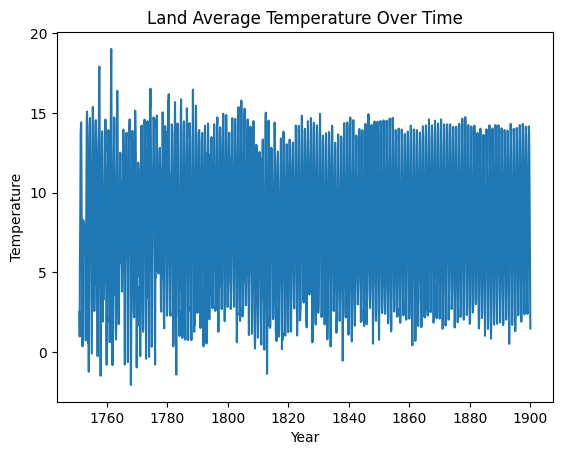

In [9]:
plt.figure()
plt.plot(df.index, y)
plt.title("Land Average Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

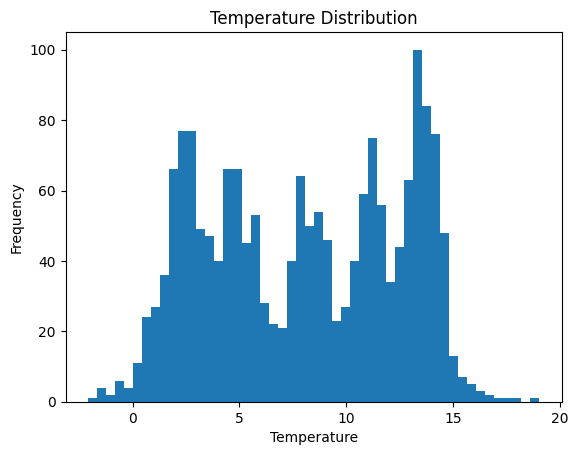

In [10]:
plt.figure()
plt.hist(y, bins=50)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = RandomizedSearchCV(
    rf,
    rf_param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)

In [ ]:
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [ ]:
results = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)



    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")


    plt.figure()
    plt.plot(y_test.values, label="Actual")
    plt.plot(preds, label="Predicted")
    plt.title(f"{name} – Actual vs Predicted")
    plt.legend()
    plt.show()


In [ ]:
results_df = pd.DataFrame(results).T
print("\nMODEL COMPARISON")
print(results_df)

best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]

print(f"\nBEST MODEL SELECTED: {best_model_name}")


In [ ]:
final_prediction = best_model.predict(X.iloc[-1:])
print("\nFINAL PREDICTION:", final_prediction)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

def cross_validate_model(model, X, y):
    rmses = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)

    return np.mean(rmses)

In [ ]:
cv_scores = {}

for name, model in models.items():
    score = cross_validate_model(model, X, y)
    cv_scores[name] = score
    print(f"{name} CV RMSE: {score:.4f}")

In [ ]:
def forecast_future(model, last_row, years=5):
    future_preds = []
    current = last_row.copy()

    for step in range(years * 12):
        pred = model.predict(current)[0]
        future_preds.append(pred)

        current["lag_12"] = current["lag_1"].values
        current["lag_1"] = pred
        current["roll_3"] = pred
        current["roll_12"] = pred

        current["month"] = (current["month"] % 12) + 1
        if current["month"].iloc[0] == 1:
            current["year"] += 1

    return future_preds

In [ ]:
future_predictions = forecast_future(best_model, X.iloc[-1:], years=10)

print("Next 10 Years Forecast (Monthly):")
print(future_predictions)

In [ ]:
last_row = df.iloc[-1]

In [ ]:
last_features_row = X.iloc[-1]

next_year = last_features_row["year"]
next_month = last_features_row["month"] + 1

if next_month > 12:
    next_month = 1
    next_year += 1

# Calculate the lagged and rolling features based on the actual target series `y`
next_lag_1 = y.iloc[-1]
next_lag_12 = y.iloc[-12]
next_roll_3 = y.iloc[-3:].mean()
next_roll_12 = y.iloc[-12:].mean()

next_input = pd.DataFrame({
    "year": [next_year],
    "month": [next_month],
    "lag_1": [next_lag_1],
    "lag_12": [next_lag_12],
    "roll_3": [next_roll_3],
    "roll_12": [next_roll_12]
})

In [ ]:
next_prediction = best_model.predict(next_input)

print(f"Predicted Land Average Temperature for {int(next_year)}-{int(next_month):02d}:",
      round(float(next_prediction[0]), 3), "°C")

In [ ]:
import joblib

joblib.dump(best_model, "best_temperature_model.pkl")
print("Model saved successfully.")